# Supplementary Figure S3 — Empirical justification of the PARSE priority-review threshold

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_ROOT = Path.cwd().parent.parent
_SUB = "supplemental" if Path.cwd().name == "supplemental_figures" else "main"
FIGURES = _ROOT / "figures" / _SUB

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / _SUB / name

In [2]:
LW = ["cWW", "tWW", "cWH", "tWH", "cWS", "tWS", "cHH", "tHH", "cHS", "tHS", "cSS", "tSS"]


CUT = 75


GOOD_C, ALL_C, POOR_C = "#2ca02c", "#1f77b4", "#d62728"


def scored_pairs(lw_only=True):
    """Unambiguous, scored per-pair records. lw_only keeps the 12 canonical LW classes."""
    raw = pd.DataFrame(json.loads(l) for l in open(data_file("reference/scores/pair_scores_uniques_parse.jsonl")))
    df = raw[~raw["is_ambiguous"] & raw["score"].notna()].copy()
    if lw_only:
        df = df[df["lw_class"].isin(LW)].copy()
    return df


def good_poor_sets():
    good = set(json.load(open(data_file("reference/reference_sets/reference_set.json")))["pdbs"])
    poor = set(json.load(open(data_file("reference/reference_sets/reference_set_poor.json")))["pdbs"])
    return good, poor


def split_good_poor(df):
    """Return (df_good, df_poor) subsets by curated / lower-quality PDB membership."""
    good, poor = good_poor_sets()
    u = df["pdb_id"].str.upper()
    return df[u.isin(good)], df[u.isin(poor)]


WEIGHTS = json.load(open(data_file("reference/scoring_tables/penalty_weights.json")))["penalty_weights"]


ISSUES = list(WEIGHTS)


def add_tier(df):
    """Add a 'tier' column: Preferred (=100) / Acceptable [75,100) / Review (<75)."""
    df = df.copy()
    df["issues"] = df["issues"].apply(lambda d: d if isinstance(d, dict) else {})
    df["tier"] = np.where(df["score"] >= 99.995, "Preferred",
                          np.where(df["score"] >= CUT, "Acceptable", "Review"))
    return df

## (A) Base-pair score ECDFs by dataset quality

Cumulative score distributions for curated, all, and lower-quality datasets.

saved figures/supplemental/figS3_A_score_ecdf_by_quality.png


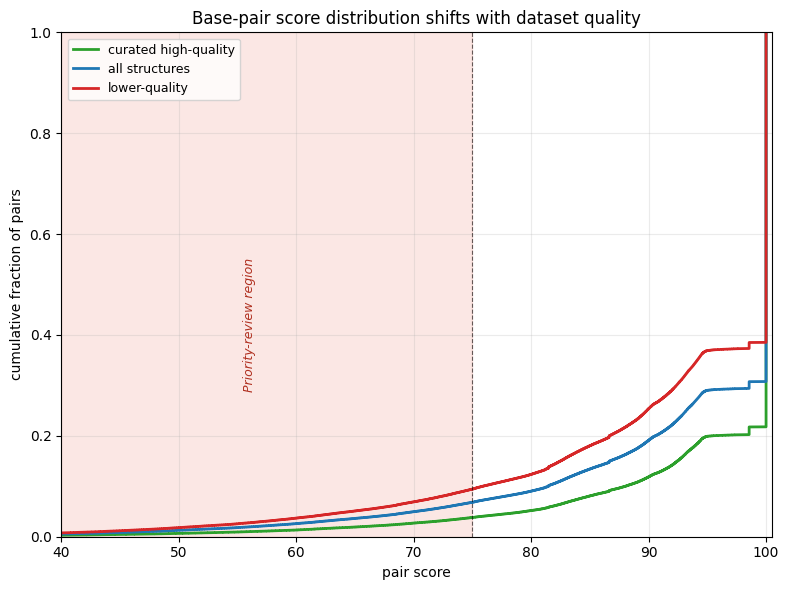

In [3]:
df = scored_pairs(lw_only=True)
df_good, df_poor = split_good_poor(df)
fig, ax = plt.subplots(figsize=(8, 6))
ax.axvspan(40, CUT, color='#e34a33', alpha=0.13, zorder=0)
ax.text(56, 0.42, 'Priority-review region', ha='center', va='center', rotation=90,
        fontsize=9, color='#b03020', style='italic')
for sub, lab, c in [(df_good, 'curated high-quality', GOOD_C),
                    (df, 'all structures', ALL_C),
                    (df_poor, 'lower-quality', POOR_C)]:
    s = np.sort(sub['score'].values)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), label=lab, color=c, lw=2.0)
ax.axvline(CUT, color='k', ls='--', lw=0.8, alpha=0.6)
ax.set_xlim(40, 100.5); ax.set_ylim(0, 1)
ax.set_xlabel('pair score'); ax.set_ylabel('cumulative fraction of pairs')
ax.set_title('Base-pair score distribution shifts with dataset quality')
ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=0.25)
fig.tight_layout(); print('saved', savefig(fig, 'figS3_A_score_ecdf_by_quality.png')); plt.show()

## (B) Priority-review fraction by dataset

Percent of pairs scoring below 75 in each dataset.

saved figures/supplemental/figS3_B_fraction_below_75_by_dataset.png


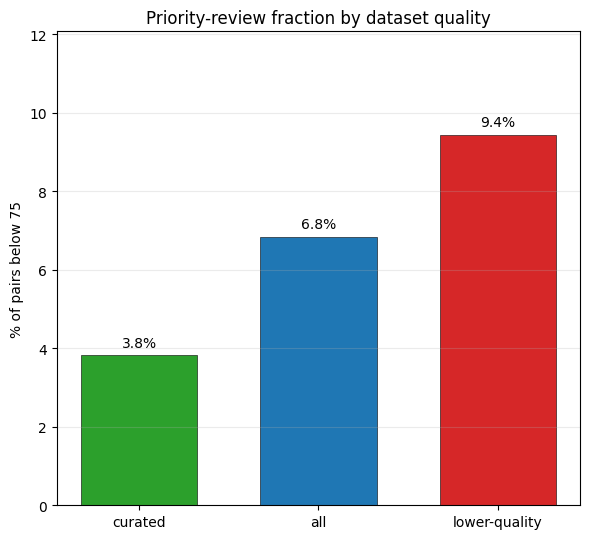

In [4]:
df = scored_pairs(lw_only=True)
df_good, df_poor = split_good_poor(df)
labs = ['curated', 'all', 'lower-quality']; cols = [GOOD_C, ALL_C, POOR_C]
vals = [100*np.mean(s['score'].values < CUT) for s in (df_good, df, df_poor)]
fig, ax = plt.subplots(figsize=(6, 5.5))
xb = np.arange(3)
ax.bar(xb, vals, color=cols, edgecolor='k', lw=0.4, width=0.65)
for xi, v in zip(xb, vals):
    ax.text(xi, v+0.15, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_xticks(xb); ax.set_xticklabels(labs)
ax.set_ylabel('% of pairs below 75'); ax.set_ylim(0, max(vals)*1.28)
ax.set_title('Priority-review fraction by dataset quality'); ax.grid(alpha=0.25, axis='y')
fig.tight_layout(); print('saved', savefig(fig, 'figS3_B_fraction_below_75_by_dataset.png')); plt.show()

## (C) Geometric-defect prevalence by tier

saved figures/supplemental/figS3_C_issue_prevalence_by_tier.png


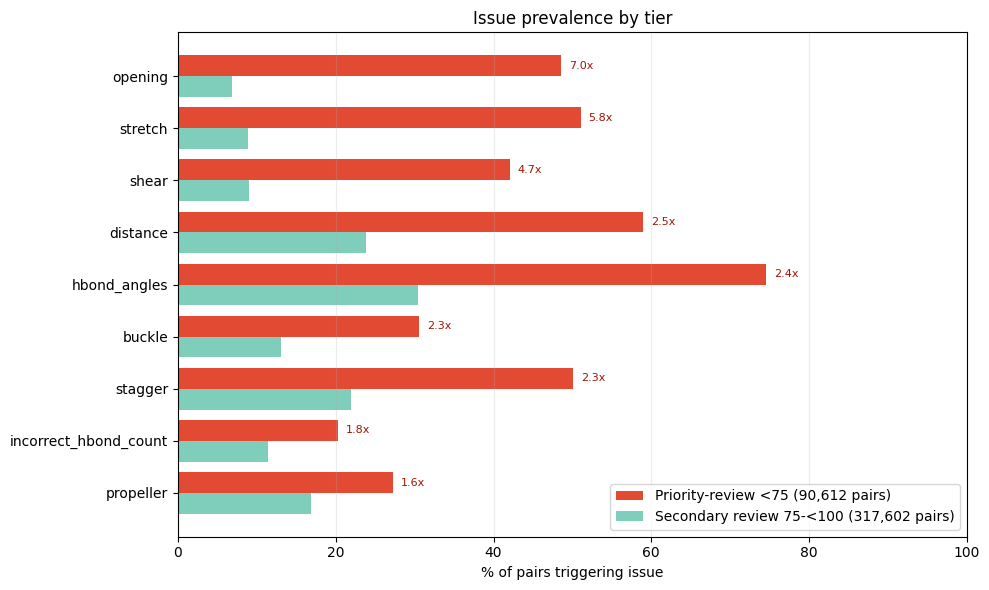

In [5]:
df = add_tier(scored_pairs(lw_only=False))
def _freq(sub):
    m = len(sub); c = {k: 0 for k in ISSUES}
    for iss in sub['issues']:
        for k in iss: c[k] += 1
    return ({k: 100*c[k]/m for k in ISSUES} if m else {k: 0 for k in ISSUES}), m
fr_R, nR = _freq(df[df['tier'] == 'Review'])
fr_A, nA = _freq(df[df['tier'] == 'Acceptable'])
enr = {k: (fr_R[k]/fr_A[k] if fr_A[k] else 0) for k in ISSUES}
row = sorted(ISSUES, key=lambda k: enr[k])
y = np.arange(len(row)); h = 0.4
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y + h/2, [fr_R[k] for k in row], h, color='#e34a33', label=f'Priority-review <75 ({nR:,} pairs)')
ax.barh(y - h/2, [fr_A[k] for k in row], h, color='#7fcdbb', label=f'Secondary review 75-<100 ({nA:,} pairs)')
for i, k in enumerate(row):
    ax.text(fr_R[k] + 1, i + h/2, f'{enr[k]:.1f}x', va='center', fontsize=8, color='#a01500')
ax.set_yticks(y); ax.set_yticklabels(row)
ax.set_xlabel('% of pairs triggering issue'); ax.set_title('Issue prevalence by tier')
ax.set_xlim(0, 100); ax.legend(loc='lower right'); ax.grid(alpha=0.25, axis='x')
fig.tight_layout(); print('saved', savefig(fig, 'figS3_C_issue_prevalence_by_tier.png')); plt.show()